In [1]:
#!connect jupyter --kernel-name pythonkernel --kernel-spec python3

The `#!connect jupyter` feature is in preview. Please report any feedback or issues at https://github.com/dotnet/interactive/issues/new/choose.

Kernel added: #!pythonkernel

# Evolutionary Algorithms

**EA** Evolutionärer Algorithmus  
**GA** Genetischer Algorithmus


## Gradienten-suche

Es ist kein konkretes Ziel vorgegeben, sondern es wird gesucht.
Es wird das bestmögliche Ziel gesucht

Stundenplan-problem:
Der tatsächliche Stundenplan ist irrelevant, wichtig ist, dass der gefundene Stundenplan für alle passt.

Der Suchalgorithmus folgt immer dem größten Gradienten. (Größten Steigung im aktuellen moment)

## Simulated Annealing

Anfangs wird stark geschüttelt, es wird eine Zufälligkeit erzeugt.
Mit Fortschreiten der suche wird die Stärke des Schüttelns reduziert.


sample:

```python
def simulated_annealing(problem):
    current = problem.startNode
    t = 0;  temp = schedule(t)

    while temp>0:
        temp = schedule(++t)

        neighbors = current.expandSuccessors()
        
        # if no neighbors, end
        if not neighbors: 
            return current

        # select random neighbor
        working = random.choice(neighbors)

        # value of node (smaller value is better)
        dE = problem.value(current) - problem.value(working)

        # if dE is positive, working is better than current
        if dE > 0):
            current = working

        # accept a random, worse node. The higher the (exponentially more likely) that happens
        if probability(math.exp(dE/temp)):
            current = working

    return current
```

Denk an das Straßennetz, nicht an eine 3D Funktion
 * temp reduziert sich schrittweise 


## Evolutionäre Algorithmen


 - Zutaten:
   * Individuen: Kodierung möglicher Lösungen
   * Population von Individuen
   * Fitnessfunktion: Bewertung der Angepasstheit

 - Mechanismen (“Operatoren”):
   * Selektion
   * Rekombination (Crossover)
   * Mutation


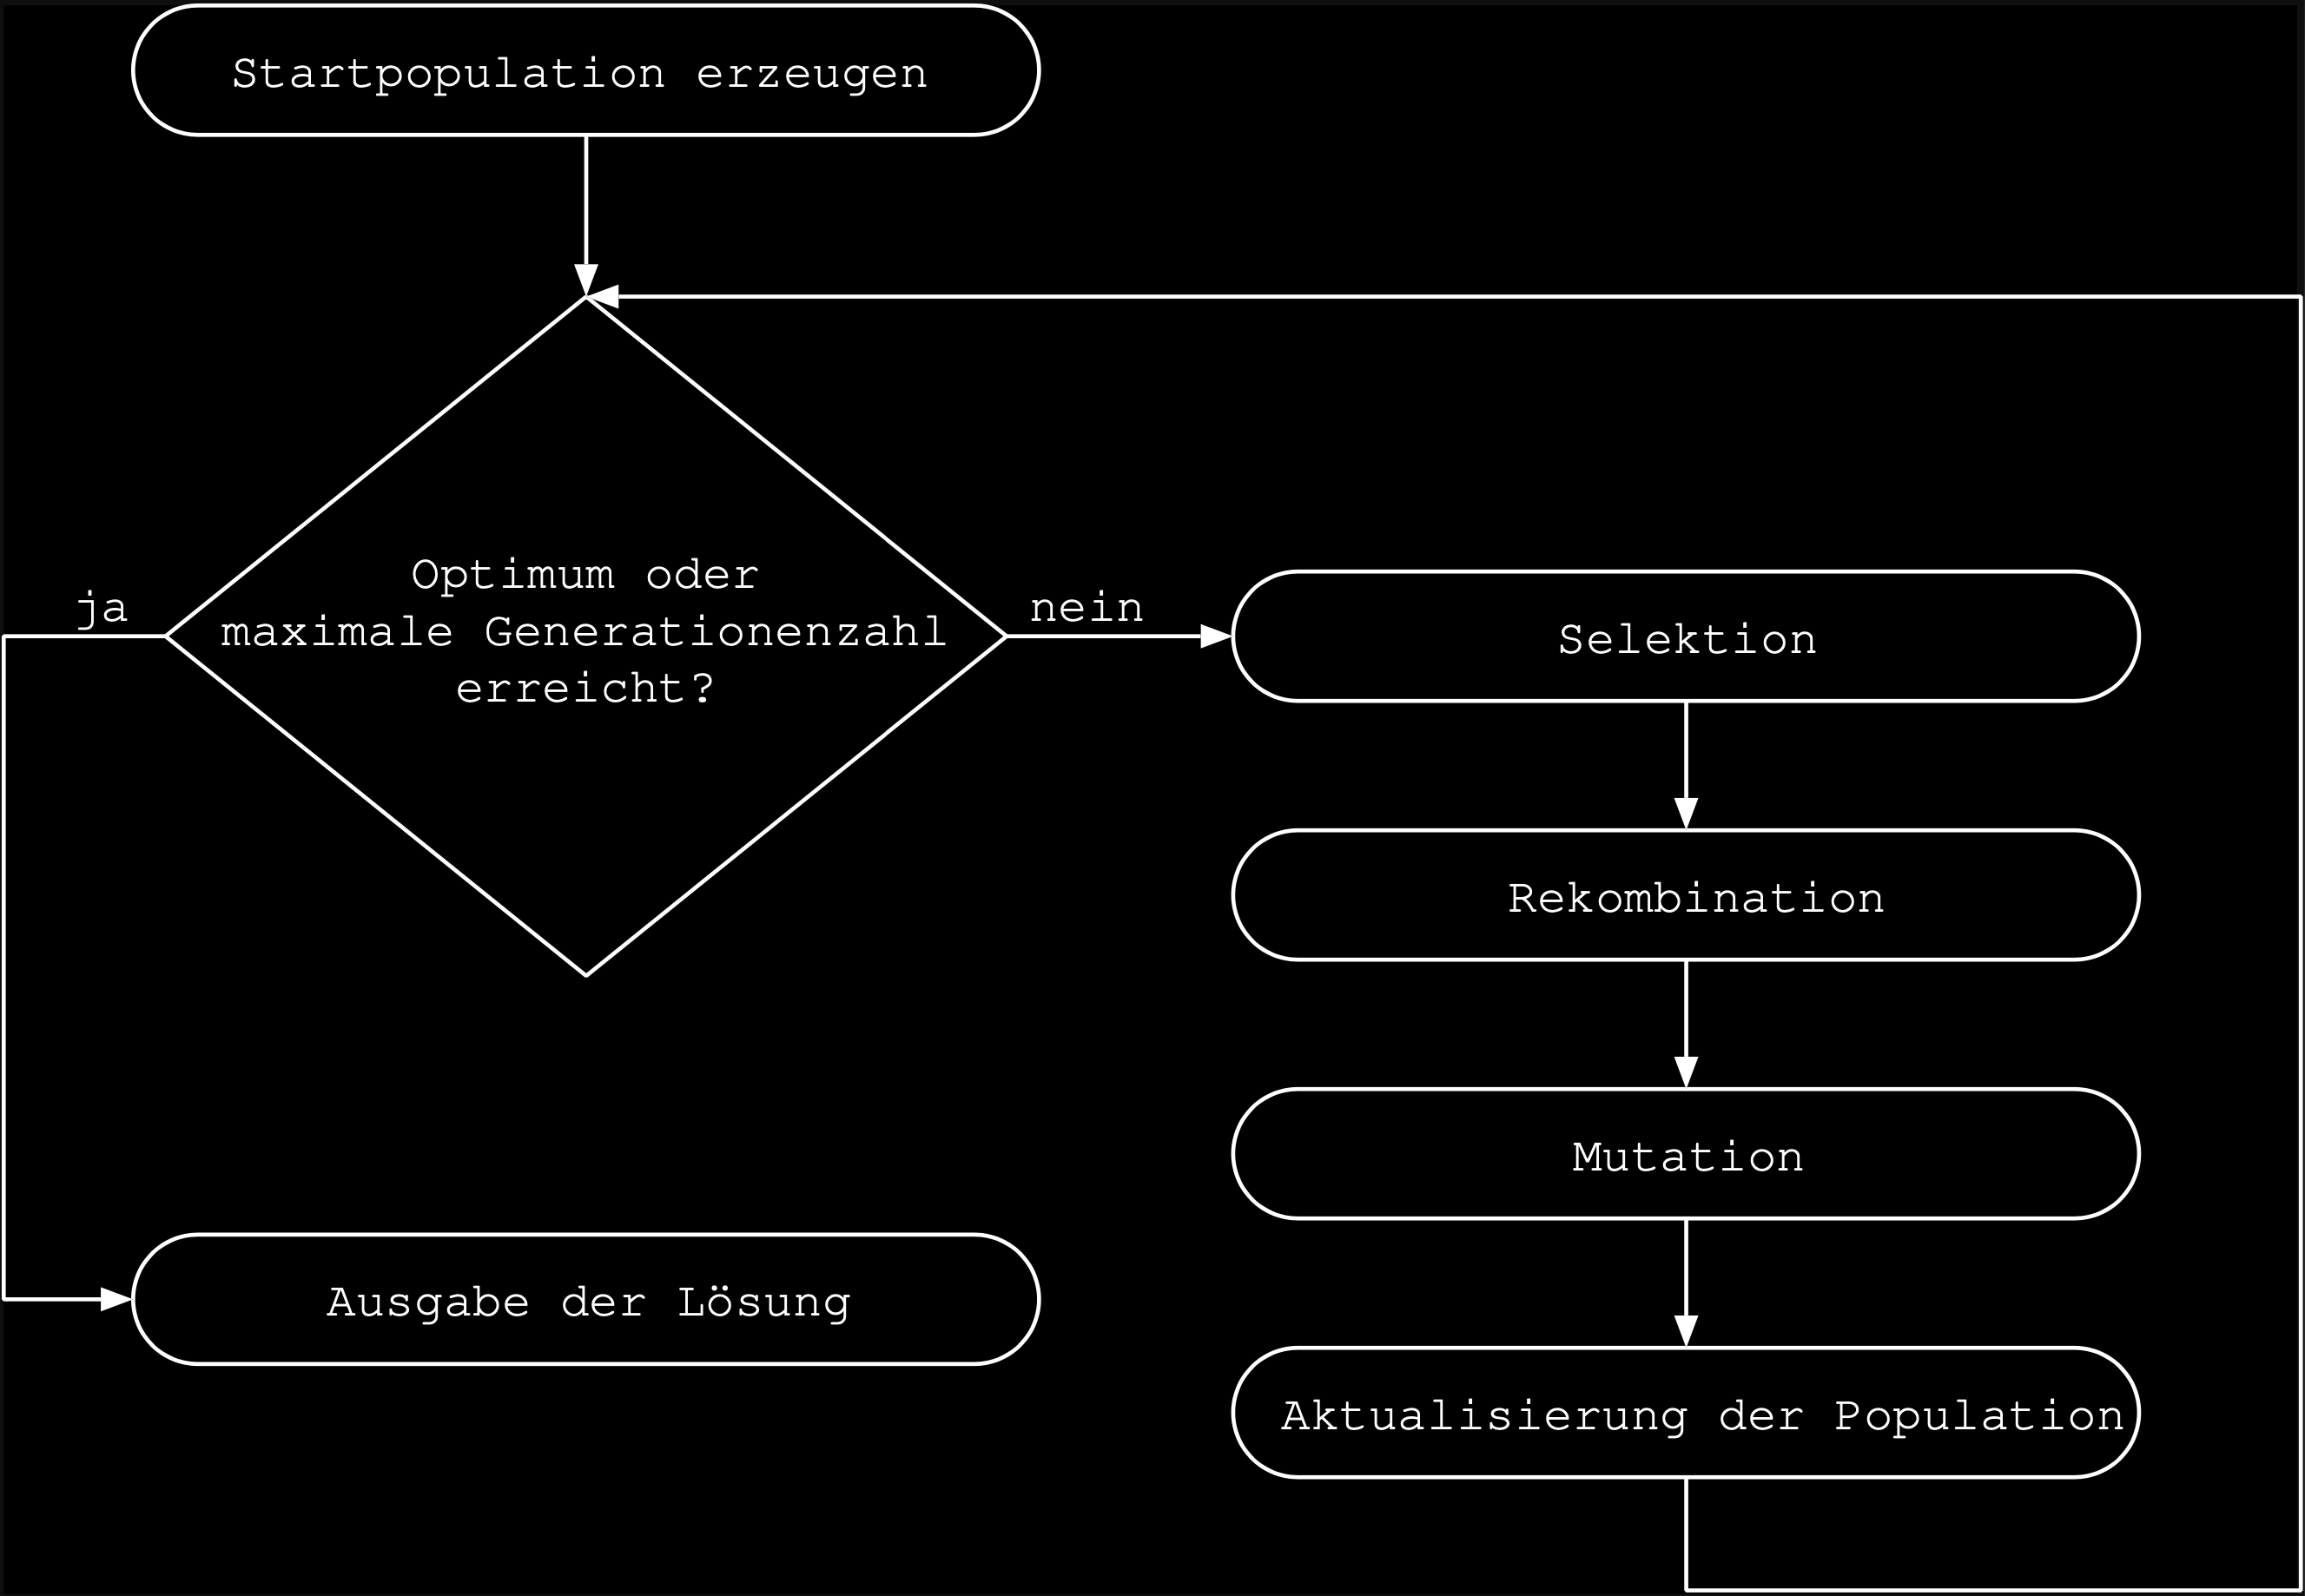

**Nur das Ergebnis zählt**

Mechanismen der Evolution

 * Es wird eine Auswahl aus der aktuellen Generation getroffen (Selektion)
 * Die Auswahl miteinander Kombiniert (Rekombination, Fortpflanzung)
 * Es werden zufällige Veränderungen erzeugt (Mutation)
 * Diese neue Generation wird wieder getestet


Population mit zufälligen Werten erzeugen.  

### Fitnessfunktion
 * Wichtig: sie steuert die Suche
 * Erstellung / Definition kann schwierig sein


### Selection

**Roulette Wheel Selection** Zufällige Auswahl. Wahrscheinlichkeit für Auswahl entsprechend der Fitness. Fitness muss positiv sein

**Turnier-Selection** Es werden N Individuen gezogen (mit zurücklegen). Daraus wird dann das Fitteste in den Matingpool kopiert.


### Rekombination / Crossover / Fortpflanzung
Eltern aus dem Matingpool ziehen

*Wahrscheinlichkeit für Crossover typisch >= 0.6. Dh. mit 0.4 Wahrscheinlichkeit werden die Kinder nicht rekombiniert*  

Eltern werden aufgetrennt und Werte werden vertauscht.


*Bei ES wird parameterweise gekreuzt. Dabei gibt es verschiedene Möglichkeiten: Übernahme eines Parameters von einem Elternteil, Verrechnen (beispielsweise Mitteln) der Werte beider Eltern, … Bei ES heißt “Crossover” deshalb oft “Rekombination”.*


### Mutation
...


[Praktikum](https://github.com/Artificial-Intelligence-HSBI-TDU/KI-Vorlesung-W25/blob/master/homework/sheet-ea.md)

# Aufgabe 1 - Modellierung von GA 


## Färben

 * Individuum: Farbzuweisung für jedes Land
 * Fitness: Anzahl der falschen Farbübergänge (jeh kleiner desto besser)
 * Crossover: Farben für einzelne Länder tauschen
 * Mutation: Farbe zufällig ändern

Die benachbarten Länder werden in einem Graphen festgehalten, der für die Fitnessfunktion verwendet wird.

Praktikum:
Ideal: ein vector der für jedes land ein eintrag enthält


## 8-Queens Problem

 * ~~Individuum: Vec2[8] Kollektion von 8 Koordinaten für jede Dame.~~ 8 Rows. Each row gets a queen in a new column. Rows get swapped.
 * Fitness: Anzahl der überlappenden Damen.
 * Crossover: Tauschen der einzelnen Vektor Komponenten mit dem äquivalent des anderen partners (eg a[1].x <=> b[1].x)
 * Mutation: Einzelne Vektor Komponente zufällig ändern
* 





# Aufgabe 2

In [2]:
#r "nuget: GeneticSharp, 3.1.4"
using GeneticSharp;

Installed Packages GeneticSharp, 3.1.4

In [3]:
interface IMap 
{
    string[] GetPlaces();
    string[] GetOptions();
    bool AreConnected(string a, string b);
    int[] GetConnections(int index);
}


class ColorChromosome : IChromosome, IBinaryChromosome
{
    private readonly IMap _map;
    private string[] _placeColors  = [];

    public ColorChromosome(IMap map)
    {
        _map = map;
    }

    public string[] Colors => _placeColors;

    public double? Fitness { 
        get => CalculateFitness(); 
        set => throw new NotImplementedException(); 
    }

    private double CalculateFitness() {
        int fitness = 0;
        for (int i = 0; i < _placeColors.Length; i++) {
            foreach (var c in _map.GetConnections(i)) {
                if (_placeColors[i] != _placeColors[c])
                    fitness++;
                else 
                    fitness--;
            }
        }
        // return fitness;
        var colorCount = _map.GetOptions().Length;
        return fitness * (1.0 - ((1.0 / colorCount) * _placeColors.Distinct().Count()));
    }


    public int Length => _placeColors.Length;

    public IChromosome Clone()
    {
        return new ColorChromosome(_map) {
            _placeColors = _placeColors
        };
    }

    public int CompareTo(IChromosome? other)
    {
        if (other is null) return 1;
        if (Fitness < other.Fitness) return -1;
        if (Fitness > other.Fitness) return 1;
        return 0;
    }

    public IChromosome CreateNew()
    {
        var o = _map.GetOptions();
        return new ColorChromosome(_map) {
            _placeColors = _map.GetPlaces().Select(_ => o[Random.Shared.Next(o.Length)]).ToArray()
        };
    }

    public Gene GenerateGene(int geneIndex)
    {
        var o = _map.GetOptions();
        var g = new Gene(o[new Random().Next(o.Length)]);
        _placeColors[geneIndex] = (string)g.Value;
        return g;
    }

    public Gene GetGene(int index)
    {
        return new Gene(_placeColors[index]);
    }

    public Gene[] GetGenes()
    {
        return _placeColors.Select(x => new Gene(x)).ToArray();
    }

    public void ReplaceGene(int index, Gene gene)
    {
        _placeColors[index] = (string)gene.Value;
    }

    public void ReplaceGenes(int startIndex, Gene[] genes)
    {
        for (int i = 0; i < genes.Length; i++)
        {
            _placeColors[startIndex + i] = (string)genes[i].Value;
        }
    }

    public void Resize(int newLength)
    {
        throw new NotImplementedException();
    }

    public void FlipGene(int index) {
        var o = _map.GetOptions();
        _placeColors[index] = o[Random.Shared.Next(o.Length)];
    }
}



In [4]:
class Map1 : IMap 
{
    public string[] GetPlaces() => ["A", "B", "C", "D", "E", "F"];
    public string[] GetOptions() => [ "Red", "Green", "Blue", "Yellow", "Purple"];
    public bool AreConnected(string a, string b) => throw new NotImplementedException();
    public int[] GetConnections(int index) => index switch {
        0 => [1, 2],
        1 => [0, 2, 3],
        2 => [0, 1, 3],
        3 => [1, 2, 4],
        4 => [3],
        5 => [],
        _ => throw new ArgumentOutOfRangeException()
    };

    public void Draw(IChromosome chromosome) {
        if (chromosome is not ColorChromosome cc)
            return;

        var colors = cc.Colors.Zip(GetPlaces());
        
        Console.WriteLine($"Assignment: {string.Join(", ", colors.Select(x => $"{x.Item2}: {x.Item1}"))}");
    }
}

var map = new Map1();


var selection = new TournamentSelection();
var crossover = new TwoPointCrossover();
var mutation = new FlipBitMutation();
var fitness = new FuncFitness(x => x.Fitness ?? 0);
var population = new Population(2, 10, new ColorChromosome(map));

var termination = new FitnessStagnationTermination();
var ga = new GeneticAlgorithm(population, fitness, selection, crossover, mutation) 
{
    Termination = termination
};

ga.GenerationRan += delegate
{
    // DrawSampleName(selectedSampleName);

    var bestChromosome = ga.Population.BestChromosome;
    // Console.WriteLine("Termination: {0}", termination);
    Console.WriteLine("Generations: {0}", ga.Population.GenerationsNumber);
    Console.WriteLine("Fitness: {0,10}", bestChromosome.Fitness);
    Console.WriteLine("Time: {0}", ga.TimeEvolving);
    Console.WriteLine("Speed (gen/sec): {0:0.0000}", ga.Population.GenerationsNumber / ga.TimeEvolving.TotalSeconds);
    map.Draw(bestChromosome);
    // sampleController.Draw(bestChromosome);
};

ga.Start()

Generations: 1
Fitness: 1.5999999999999996
Time: 00:00:00.0022674
Speed (gen/sec): 441.0338
Assignment: A: Blue, B: Blue, C: Yellow, D: Blue, E: Purple, F: Yellow
Generations: 2
Fitness: 1.5999999999999996
Time: 00:00:00.0022674
Speed (gen/sec): 882.0676
Assignment: A: Blue, B: Blue, C: Yellow, D: Blue, E: Purple, F: Yellow
Generations: 3
Fitness: 1.5999999999999996
Time: 00:00:00.0074967
Speed (gen/sec): 400.1761
Assignment: A: Blue, B: Blue, C: Yellow, D: Blue, E: Purple, F: Yellow
Generations: 4
Fitness: 1.5999999999999996
Time: 00:00:00.0076481
Speed (gen/sec): 523.0057
Assignment: A: Blue, B: Blue, C: Yellow, D: Blue, E: Purple, F: Yellow
Generations: 5
Fitness: 1.5999999999999996
Time: 00:00:00.0084338
Speed (gen/sec): 592.8526
Assignment: A: Blue, B: Blue, C: Yellow, D: Blue, E: Purple, F: Yellow
Generations: 6
Fitness: 1.5999999999999996
Time: 00:00:00.0085211
Speed (gen/sec): 704.1344
Assignment: A: Blue, B: Blue, C: Yellow, D: Blue, E: Purple, F: Yellow
Generations: 7
Fitness

## 8-Damen

In [5]:
class QueensChromosome : IChromosome, IBinaryChromosome
{
    private readonly int _width;
    private readonly int _height;
    private readonly int _queens;

    private int[] _positions;


    public QueensChromosome(int width, int height, int queens)
    {
        _width = width;
        _height = height;
        _queens = queens;

        _positions = new int[queens * 2];
    }

    public IEnumerable<(int X, int Y)> GetQueens() 
    {
        for (int i = 0; i < _positions.Length - 1; i += 2)
            yield return (_positions[i + 0], _positions[i + 1]);
    }

    public double CalculateFitness() 
    {
        // var queens = GetQueens().ToArray();
        // if (queens.Distinct().Count() != queens.Length)
        //     return -1;

        // // var fitness = Math.Pow(2, CalculateInterfereCount());



        // // int fitness = 1000;
        // double fitness = 1;
        // for (int i = 0; i < queens.Length - 1; i++) {
        //     for (int j = i + 1; j < queens.Length; j++){
        //         var a = queens[i];
        //         var b = queens[2];

        //         if (!QueensInterfere(a, b)) {
        //             fitness++;
        //             // fitness *= 2;
        //         }

        //         // if (!QueensInterfere(a, b)) {
        //         //     // fitness++;
        //         //     fitness /= 2;
        //         // }
        //     }
        // }

        // if (queens.Select(x => x.X).Distinct().Count() < _queens)
        //     fitness *= 0.1;
        //     // return -1;

        // if (queens.Select(x => x.Y).Distinct().Count() < _queens)
        //     fitness *= 0.1;
        //     // return -1;

        // return fitness;
        return CalculateInterfereCount() * -1.0;
    }

    public int CalculateInterfereCount() 
    {
        int interference = 0;

        var queens = GetQueens().ToArray();

        for (int i = 0; i < queens.Length - 1; i++) {
            for (int j = i + 1; j < queens.Length; j++){
                var a = queens[i];
                var b = queens[2];

                if (QueensInterfere(a, b))
                    interference++;
            }
        }

        return interference;
    }

    public static bool QueensInterfere((int, int) a, (int, int) b) 
    {
        if (a.Item1 == b.Item1)
            return true;
        if (a.Item2 == b.Item2)
            return true;

        // Diagonals
        if (Math.Abs(b.Item2 - a.Item2) == Math.Abs(b.Item1 - a.Item1))
            return true;
        if (Math.Abs(a.Item2 - b.Item2) == Math.Abs(a.Item1 - b.Item1))
            return true;

        return false;
    }


    public int Length => _positions.Length;

    public double? Fitness 
    { 
        get => CalculateFitness(); 
        set => throw new NotImplementedException(); 
    }

    public IChromosome Clone()
    {
        return new QueensChromosome(_width, _height, _queens) {
            _positions = _positions.ToArray()
        };
    }

    public int CompareTo(IChromosome? other)
    {
        if (other is null)
            return 1;
        if (Fitness > other.Fitness)
            return 1;
        if (Fitness < other.Fitness)
            return -1;
        return 0;
    }

    public IChromosome CreateNew()
    {
        var c = new QueensChromosome(_width, _height, _queens);
        for (int i = 0; i < c._positions.Length; i++)
        {
            var limit = (i % 2 == 0) ? _width : _height;
            c._positions[i] = Random.Shared.Next(limit);
        }
        return c;
    }

    public Gene GenerateGene(int geneIndex)
    {
        var limit = (geneIndex % 2 == 0) ? _width : _height;
        _positions[geneIndex] = Random.Shared.Next(limit);

        return new Gene(_positions[geneIndex]);
    }

    public Gene GetGene(int index)
    {
        return new Gene(_positions[index]);
    }

    public Gene[] GetGenes()
    {
        return _positions.Select(x => new Gene(x)).ToArray();
    }

    public void ReplaceGene(int index, Gene gene)
    {
        var limit = (index % 2 == 0) ? _width : _height;
        _positions[index] = (int)gene.Value % limit;
    }

    public void ReplaceGenes(int startIndex, Gene[] genes)
    {
        for (int i = 0; i < genes.Length; i++) {
            ReplaceGene(i + startIndex, genes[i]);
        }
    }

    public void Resize(int newLength)
    {
        throw new NotImplementedException();
    }

    public void FlipGene(int index) {
        _positions[index] = Random.Shared.Next(0, _queens);
    }

    public void DrawSimple() {
        Console.WriteLine($"Collisions: {CalculateInterfereCount()}");
    }

    public void Draw() {
        var queens = GetQueens().ToArray();

        for (int j = 0; j < _height; j++) {
            for (int i = 0; i < _width; i++){
                if (queens.Contains((i, j))) 
                    Console.Write("[o]");
                else
                    Console.Write("[ ]");
            }
            Console.WriteLine();
        }
    }
}

var selection = new RankSelection();
var crossover = new OnePointCrossover();
var mutation = new FlipBitMutation(){ };
var fitness = new FuncFitness(x => (x.Fitness ?? 0));
var population = new Population(100, 1000, new QueensChromosome(8, 8, 8));

// var termination = new FitnessStagnationTermination();
var termination = new OrTermination(new GenerationNumberTermination(200000), new FitnessThresholdTermination(-2));
var ga = new GeneticAlgorithm(population, fitness, selection, crossover, mutation) 
{
    Termination = termination
};

var oldBest = 0.0;
ga.GenerationRan += delegate
{
    // DrawSampleName(selectedSampleName);
    var bestChromosome = ga.Population.BestChromosome;
    if (oldBest == bestChromosome.Fitness)
        return;
    oldBest = bestChromosome.Fitness ?? 0;

    // Console.WriteLine("Termination: {0}", termination);
    Console.WriteLine("Generations: {0}", ga.Population.GenerationsNumber);
    Console.WriteLine("Fitness: {0,10}", bestChromosome.Fitness);
    // Console.WriteLine("Time: {0}", ga.TimeEvolving);
    // Console.WriteLine("Speed (gen/sec): {0:0.0000}", ga.Population.GenerationsNumber / ga.TimeEvolving.TotalSeconds);
    ((QueensChromosome)bestChromosome).DrawSimple();
};

ga.Start();


var finalBest = ga.Population.BestChromosome;
Console.WriteLine("Generations: {0}", ga.Population.GenerationsNumber);
Console.WriteLine("Fitness: {0,10}", finalBest.Fitness);
((QueensChromosome)finalBest).DrawSimple();
((QueensChromosome)finalBest).Draw();
// Console.WriteLine("Done!");


Generations: 1
Fitness:         -5
Collisions: 5
Generations: 200000
Fitness:         -5
Collisions: 5
[ ][ ][ ][ ][ ][o][o][ ]
[ ][ ][ ][ ][ ][ ][ ][ ]
[ ][ ][ ][ ][ ][ ][ ][ ]
[ ][ ][ ][ ][ ][ ][o][ ]
[ ][ ][ ][ ][ ][ ][o][ ]
[ ][o][ ][ ][ ][ ][ ][o]
[o][ ][ ][ ][ ][ ][ ][ ]
[ ][ ][ ][ ][o][ ][ ][ ]



# Aufgabe 3

## Where is Waldo

 * Fitness-funktion: Totale Länge des Pfades
 * Individuen: (x, y) Koordinaten von Waldos Positionen
 * Operatoren: 
   + Selection: Take the top 10% shortest paths and produce offspring from each of them
   + Crossover: 4 offsprings with 1-3 mutations
   + Mutation: [5] Es wird ein Teilpfad zufällig an eine andere Stelle verschoben. (shuffle)

## Evolution-Simulator
 * Fitness-funktion: Größte zurückgelegte Distanz nach rechts in 15s
 * Individuen: Nodes die mit Muskeln verbunden sind. Eine Node hat eine bestimmte Reibung. Muskeln haben eine länge, eine Zykluszeit und eine stärke
 * Operatoren: 
   + Selection: Die besten 50% werden ausgewählt. Mit ein wenig Noise, so das auch ein paar gute sterben und ein paar schlechte überleben

## american fuzzy lop
Der fuzzer läd eine Enigabedatei und für das zu testende Program darauf aus. 
In weiteren durchläufen verändert der AFL die Datei byte-weise an einigen Stellen und führt das Program erneut mit den neu generierten Dateien aus. Da bei analysiert der AFL das Program wären der Ausführung und kann erkennen, dass das es mit bestimmten eingaben anders oder weiter ausführt. Auf dieser basis setzt der AFL auf und erzeugt weitere, ähnliche Dateien, um das Program zu testen. 


# Post Mortem

Jede Person beschreibt in der ILIAS-Abgabe individuell(!) die Bearbeitung des jeweiligen Aufgabenblattes
zurückblickend mit ca. 200 bis 400 Wörtern. Gehen Sie dabei aussagekräftig und nachvollziehbar auf folgende Punkte ein: 
 (a) Zusammenfassung: Was wurde gemacht?   
 (b) Implementierungsdetails: Kurze Beschreibung besonders interessanter Aspekte der Umsetzung.  
 (c) Was war der schwierigste Teil bei der Bearbeitung? Wie haben Sie dieses Problem gelöst?  
 (d) Was haben Sie gelernt oder (besser) verstanden?  
 (e) Team: Mit wem haben Sie zusammengearbeitet?  
 (f) Link zum Repo mit der Lösung  

 

  * a-b: Ich habe die Aufgabe 2 in einem .NET Notebook mit C# bearbeitet. Für die GA habe ich die GeneticSharp library benutzt. Ich habe für beide Aufgaben jeweils eine Klasse erstellt, welche das IChromosom interface implementiert. Diese Klasse hält die Gene eines Individuums und wird von der Library verwendet, um den Genetischen Algorithmus.  Für Aufgabe 3 habe ich die Inhalte hinter den links angeschaut und die Details dazu aufgeschrieben.
  * c: Ich habe Anfangs nicht richtig verstanden, was ich machen soll. Ich glaube, dass es hilfreicher gewesen wäre, wenn ich Aufgabe 3 zu erste bearbeitet hätte. Zu schauen, was andere ein Problem gelöst haben hilft mir zu verstehen, was ich selbst machen soll. Mehr knappe, übersichtliche Beispiele fände ich gut.
  * d: Die grundsätzliche Konzept hinter einem GA finde ich eigentlich ziemlich klar. Die Implementierung hat mir ein wenig Probleme gemacht. Insbesondere bei dem Damen Problem bin ich mir noch nicht sicher, ob meine Lösung vernünftig ist.
  * e: -
  * f: https://github.com/co1inco/IFM_Programieren3/tree/master/KI/3